# Task 1: Student Score Prediction

Predicting student exam scores using a linear regression model based on study hours (with bonus experiments).

**Pipeline** : Load data → Clean & explore → Visualize → Split → Train Linear Regression → Evaluate → (Bonus) Poly/feature experiments → Gradio app

## 1. Imports & Data Loading

In [3]:
# Install required libraries (run once)
import sys
import subprocess

required = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "gradio"]
for pkg in required:
    try:
        __import__(pkg)
        print(f"{pkg} already installed")
    except ImportError:
        print(f"Installing {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

Installing numpy...
Installing pandas...
Installing matplotlib...
Installing seaborn...
Installing scikit-learn...
Installing gradio...


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
DATA_PATH = r"D:\summerToTheFinal\elevvo\elevvo_projects\project_1\StudentPerformanceFactors.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head(20)

Dataset shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


## 2. Data Cleaning & Overview

In [6]:
# Basic information
print("Dataset info:")
print(f"- Rows: {len(df)}, Columns: {len(df.columns)}")
print(f"- Duplicates: {df.duplicated().sum()}")
print()

# Missing values per column
print("Missing values per column:")
print(df.isna().sum())
print()

# Data types
print("Data types:")
print(df.dtypes.value_counts())

Dataset info:
- Rows: 6607, Columns: 20
- Duplicates: 0

Missing values per column:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Data types:
str      13
int64     7
Name: count, dtype: int64


In [7]:
# Inspect missing values
missing_cols = df.isna().sum()
missing_cols = missing_cols[missing_cols > 0]
print("Columns with missing values:")
print(missing_cols)

# Show rows with missing values in one column (e.g. Teacher_Quality)
df[df["Teacher_Quality"].isna()].head()

Columns with missing values:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
127,17,97,Medium,Medium,No,8,89,Medium,Yes,1,Low,NaN,Public,Neutral,4,No,High School,Far,Male,69
396,10,80,High,Medium,Yes,6,93,High,Yes,4,Medium,NaN,Public,Negative,3,No,College,Moderate,Female,67
457,14,86,Medium,Low,Yes,8,90,Medium,No,3,Medium,NaN,Public,Negative,3,Yes,Postgraduate,Near,Male,65
570,20,71,High,Medium,No,8,77,Medium,Yes,0,High,NaN,Private,Neutral,4,No,High School,Moderate,Male,66
593,22,82,High,Medium,Yes,7,71,Low,Yes,1,High,NaN,Private,Positive,3,No,High School,Near,Female,69


In [8]:
# Handle missing values in categorical columns by filling with the mode (most frequent value)
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"Filled {df[col].isna().sum()} missing values in '{col}' with '{mode_val}'")

# Confirm no missing values remain
print("\nTotal missing values after cleaning:", df.isna().sum().sum())

# Descriptive statistics for numeric columns
print("\nDescriptive statistics (numeric columns):")
df.describe()

Filled 0 missing values in 'Teacher_Quality' with 'Medium'
Filled 0 missing values in 'Parental_Education_Level' with 'High School'
Filled 0 missing values in 'Distance_from_Home' with 'Near'

Total missing values after cleaning: 0

Descriptive statistics (numeric columns):


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## 3. Data Visualization

Let's understand the distribution of exam scores and the relationship between study hours and exam scores.

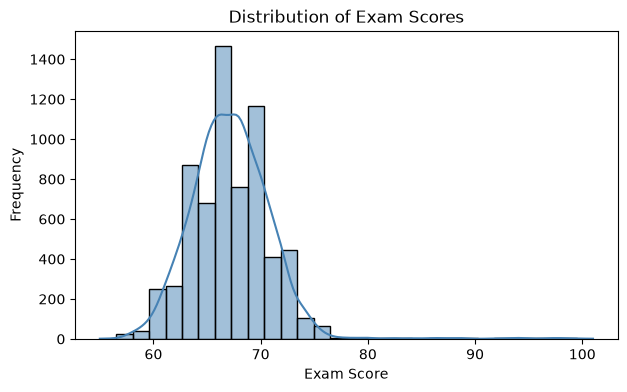

In [9]:
# Figure 1: Distribution of Exam_Score
plt.figure(figsize=(7, 4))
sns.histplot(df["Exam_Score"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

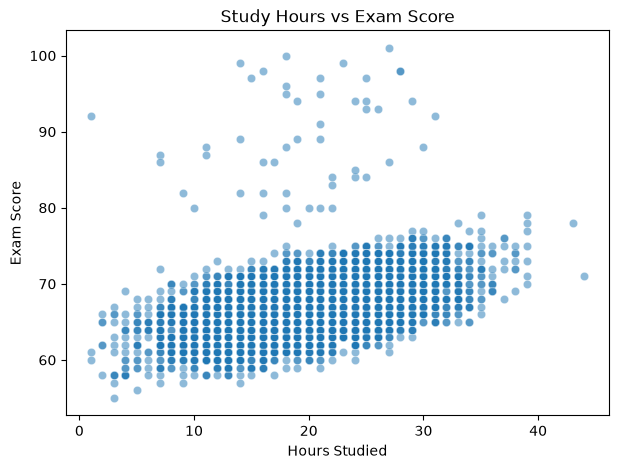

In [10]:
# Figure 2: Study hours vs Exam score (core relationship)
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df, alpha=0.5)
plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

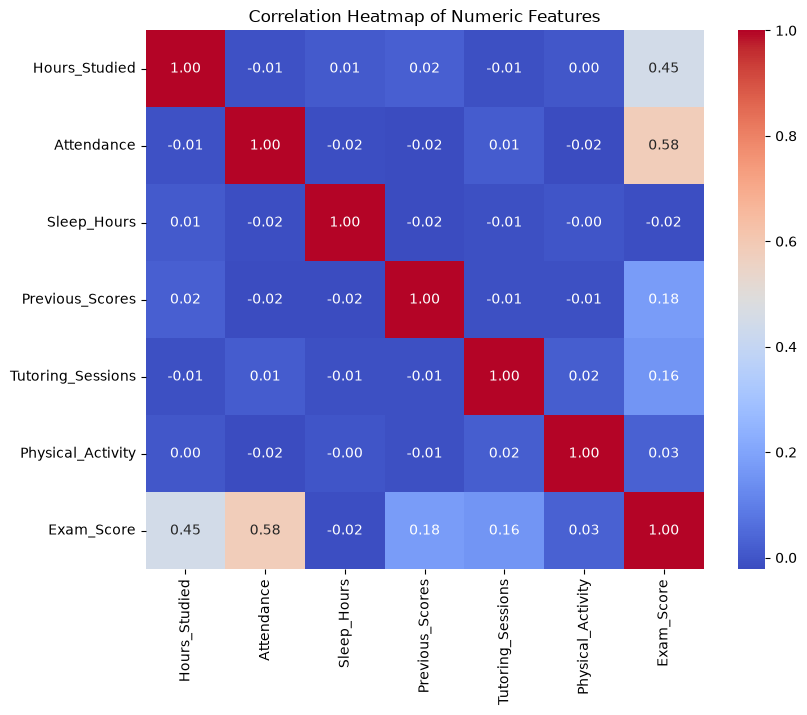

Correlation with Exam_Score:
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [11]:
# Figure 3: Correlation heatmap of numeric features
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

# Print correlation of each feature with Exam_Score
corr_with_target = df[numeric_cols].corr()['Exam_Score'].drop('Exam_Score').sort_values(ascending=False)
print("Correlation with Exam_Score:")
print(corr_with_target)

## 4. Train/Test Split & Linear Regression

**Core model**: predict `Exam_Score` using only `Hours_Studied`.

In [12]:
# Core model: use Hours_Studied as the single feature
X = df[["Hours_Studied"]]   # feature is 2D for sklearn
y = df["Exam_Score"]        # target

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing  set size: {X_test.shape[0]} rows")

Training set size: 5285 rows
Testing  set size: 1322 rows


In [13]:
# Train a linear regression model on study hours
model = LinearRegression()
model.fit(X_train, y_train)

# Inspect the learned equation: Exam_Score = intercept + coefficient * Hours_Studied
intercept = model.intercept_
coef = model.coef_[0]
print(f"Linear model: Exam_Score = {intercept:.2f} + ({coef:.2f} * Hours_Studied)")

Linear model: Exam_Score = 61.51 + (0.29 * Hours_Studied)


## 5. Visualize Predictions & Evaluate Performance

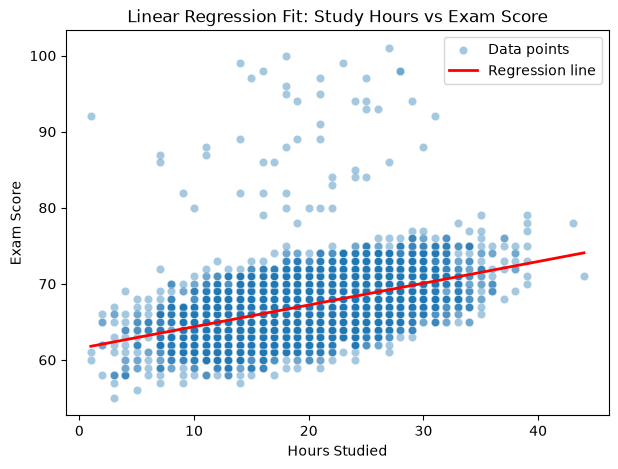

In [14]:
# Regression line over the full range of study hours
hours_range = np.linspace(df["Hours_Studied"].min(), df["Hours_Studied"].max(), 100).reshape(-1, 1)
pred_line = model.predict(hours_range)

plt.figure(figsize=(7, 5))
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df, alpha=0.4, label="Data points")
plt.plot(hours_range, pred_line, color="red", linewidth=2, label="Regression line")
plt.title("Linear Regression Fit: Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.show()

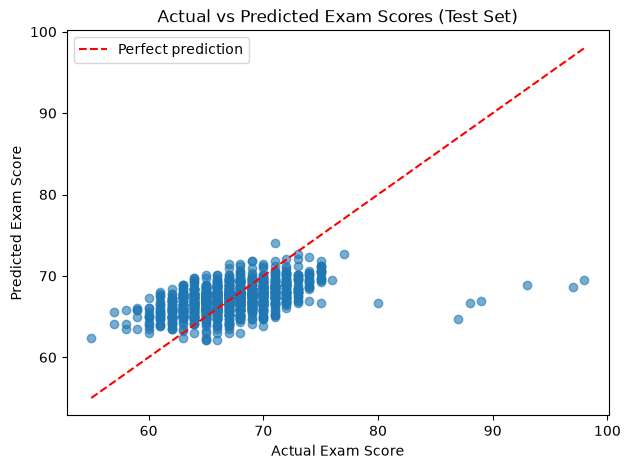

In [15]:
# Predict on the test set
y_pred = model.predict(X_test)

# Actual vs Predicted scatter
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", label="Perfect prediction")
plt.title("Actual vs Predicted Exam Scores (Test Set)")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.legend()
plt.show()

In [16]:
# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance (Linear Regression on Hours_Studied only):")
print(f"  MAE  : {mae:.2f}")
print(f"  MSE  : {mse:.2f}")
print(f"  RMSE : {rmse:.2f}")
print(f"  R^2  : {r2:.4f}")

Model Performance (Linear Regression on Hours_Studied only):
  MAE  : 2.45
  MSE  : 10.86
  RMSE : 3.29
  R^2  : 0.2320


## 6. Bonus: Polynomial Regression Comparison

Linear models assume a straight-line relationship. Let's see if a polynomial fit on study hours performs better.

In [24]:
from sklearn.pipeline import make_pipeline

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
    }

results = []
# Degree 1 = linear (baseline), then polynomial degrees 2 and 3
for degree in [1, 2, 3]:
    pipe = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())
    metrics = evaluate_model(pipe, X_train, X_test, y_train, y_test)
    results.append({"Model": f"Degree {degree}", **metrics})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   Model       R2     RMSE      MAE
Degree 1 0.231987 3.294833 2.447569
Degree 2 0.232760 3.293173 2.444780
Degree 3 0.232842 3.292998 2.444512


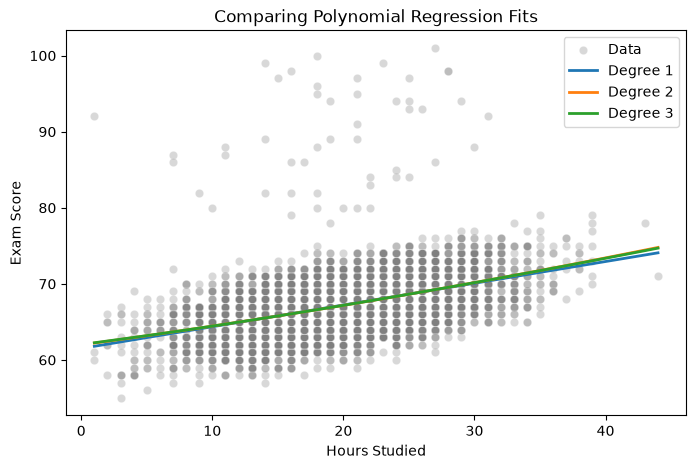

In [18]:
# Visualize the polynomial fits
degrees = [1, 2, 3]
plt.figure(figsize=(8, 5))
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df, alpha=0.3, color="gray", label="Data")

for deg in degrees:
    pipe = make_pipeline(PolynomialFeatures(degree=deg), LinearRegression())
    pipe.fit(X_train, y_train)
    pred = pipe.predict(hours_range)
    plt.plot(hours_range, pred, linewidth=2, label=f"Degree {deg}")

plt.title("Comparing Polynomial Regression Fits")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.legend()
plt.show()

## 7. Bonus: Feature Combination Experiments

Test different feature sets (adding/removing features) and compare performance.

In [19]:
from sklearn.preprocessing import OneHotEncoder

# Prepare a version with extra numeric features plus one-hot encoded categoricals
categorical_cols = [
    "Parental_Involvement", "Access_to_Resources", "Extracurricular_Activities",
    "Motivation_Level", "Internet_Access", "Family_Income", "Teacher_Quality",
    "School_Type", "Peer_Influence", "Learning_Disabilities",
    "Parental_Education_Level", "Distance_from_Home", "Gender",
]
numeric_extra = ["Attendance", "Sleep_Hours", "Previous_Scores", "Tutoring_Sessions", "Physical_Activity"]

# One-hot encode categorical features for a full-data model
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Encoded shape:", df_encoded.shape)

feature_sets = {
    "Hours only": ["Hours_Studied"],
    "Hours + numeric": ["Hours_Studied"] + numeric_extra,
    "All features": None,  # all encoded columns except target
}

for name, feats in feature_sets.items():
    if feats is None:
        X_feat = df_encoded.drop(columns=["Exam_Score"])
    else:
        X_feat = df_encoded[feats]
    Xtr, Xte, ytr, yte = train_test_split(X_feat, y, test_size=0.2, random_state=42)
    metrics = evaluate_model(LinearRegression(), Xtr, Xte, ytr, yte)
    metrics["Features"] = name
    metrics["# Features"] = X_feat.shape[1]
    results.append(metrics)

feature_results = pd.DataFrame(results)
print(feature_results[["Features", "# Features", "R2", "RMSE", "MAE"]].to_string(index=False))

Encoded shape: (6607, 28)
       Features  # Features       R2     RMSE      MAE
            NaN         NaN 0.231987 3.294833 2.447569
            NaN         NaN 0.232760 3.293173 2.444780
            NaN         NaN 0.232842 3.292998 2.444512
     Hours only         1.0 0.231987 3.294833 2.447569
Hours + numeric         6.0 0.641639 2.250657 1.265856
   All features        27.0 0.769650 1.804445 0.452392


## 8. Gradio Interactive App

Turn the trained model into a simple web UI. Run the cells below (you only need this section when you want the UI).

> **Note**: Install gradio once with: `pip install gradio`

In [20]:
# Refit a simple model on the full Hours_Studied feature for the Gradio app
simple_model = LinearRegression()
simple_model.fit(X, y)
print(f"App model: Exam_Score = {simple_model.intercept_:.2f} + ({simple_model.coef_[0]:.2f} * Hours_Studied)")

App model: Exam_Score = 61.46 + (0.29 * Hours_Studied)


In [22]:
import gradio as gr

def predict_score(hours):
    if hours is None or hours < 0:
        return None
    pred = simple_model.predict([[hours]])[0]
    return round(float(pred), 2)

demo = gr.Interface(
    fn=predict_score,
    inputs=gr.Number(label="Hours Studied", value=20),
    outputs=gr.Number(label="Predicted Exam Score"),
    title="Student Score Prediction",
    description="Enter study hours to predict the exam score using a linear regression model.",
)
demo.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
